Loading v0d_off:
  ipsi (LEFT):   /Users/angusgray/Desktop/rg_csv/v0d_off/LEFT_output_rg1.csv
  contra (RIGHT): /Users/angusgray/Desktop/rg_csv/v0d_off/RIGHT_output_rg1.csv
Saved: /Users/angusgray/Desktop/rg_csv/figures/v0d_off_ipsi_contra.png
Saved: /Users/angusgray/Desktop/rg_csv/figures/v0d_off_ipsi_contra.svg
Loading v3_off:
  ipsi (LEFT):   /Users/angusgray/Desktop/rg_csv/v3_off/LEFT_output_rg1.csv
  contra (RIGHT): /Users/angusgray/Desktop/rg_csv/v3_off/RIGHT_output_rg1.csv
Saved: /Users/angusgray/Desktop/rg_csv/figures/v3_off_ipsi_contra.png
Saved: /Users/angusgray/Desktop/rg_csv/figures/v3_off_ipsi_contra.svg
Loading healthy:
  ipsi (LEFT):   /Users/angusgray/Desktop/rg_csv/healthy/LEFT_output_rg1.csv
  contra (RIGHT): /Users/angusgray/Desktop/rg_csv/healthy/RIGHT_output_rg1.csv
Saved: /Users/angusgray/Desktop/rg_csv/figures/healthy_ipsi_contra.png
Saved: /Users/angusgray/Desktop/rg_csv/figures/healthy_ipsi_contra.svg


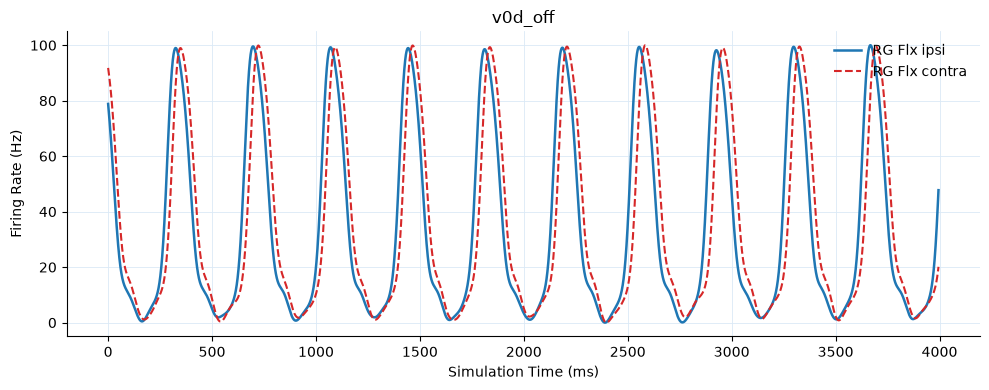

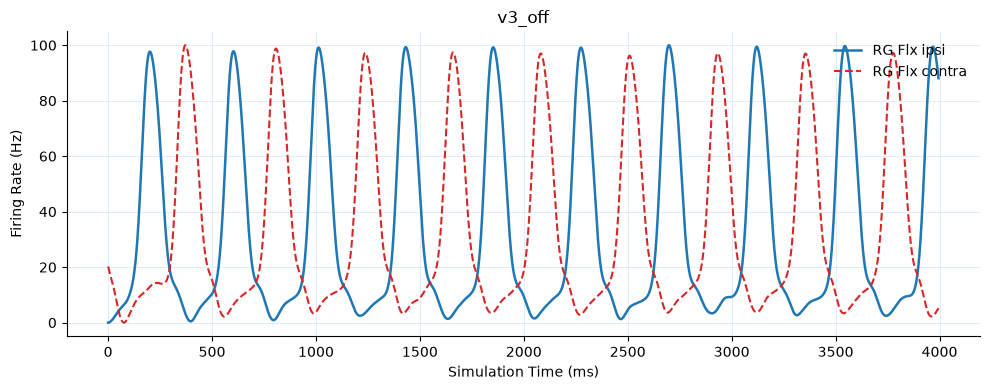

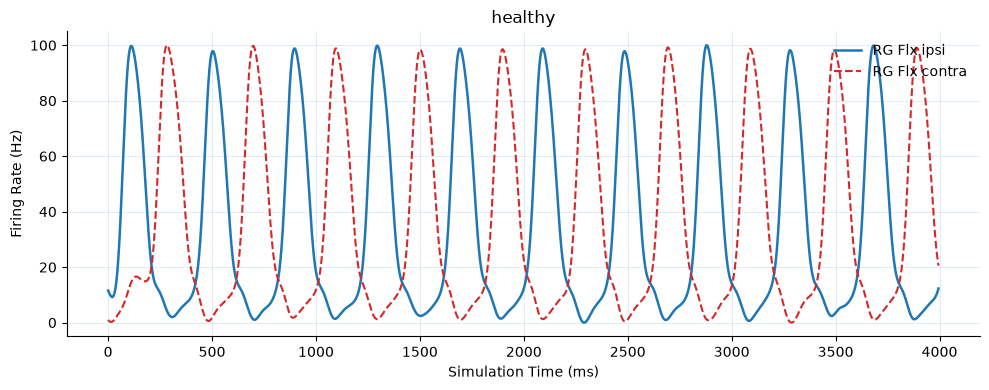

In [13]:
"""
Plot overlapping ipsi (LEFT) vs contra (RIGHT) firing-rate traces from
rhythm-generator CSV outputs.

These CSVs are written with:
    np.savetxt(f'/{label}_output_rg1.csv', rg1_convolved_scaled, delimiter=',')

i.e. a single 1D array of firing-rate values, ONE PER LINE, with no header
and no time column. Time has to be reconstructed from the sample index using
the bin width (DT_MS) used inside convolve_spiking_activity.

>>> IMPORTANT: set DT_MS below to match your actual bin size. <<<
If you're not sure, check the bin_size / dt argument passed into
convolve_spiking_activity (or the simulation dt if the convolution uses one
bin per timestep). Wrong DT_MS will just stretch/compress the x-axis - the
shape of the trace itself will still be correct.

Expected on-disk layout (adjust CONDITIONS below to match yours):
    /Users/angusgray/Desktop/rg_csv/v0d_off/LEFT_output_rg1.csv
    /Users/angusgray/Desktop/rg_csv/v0d_off/RIGHT_output_rg1.csv
    /Users/angusgray/Desktop/rg_csv/v3_off/LEFT_output_rg1.csv
    /Users/angusgray/Desktop/rg_csv/v3_off/RIGHT_output_rg1.csv
"""

import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# EDIT THESE to match your setup
# ---------------------------------------------------------------------------
DT_MS = 0.1   

CONDITIONS = {
    "v0d_off": {
        "dir": r"/Users/angusgray/Desktop/rg_csv/v0d_off/",
        "left_file": "LEFT_output_rg1.csv",   # ipsi
        "right_file": "RIGHT_output_rg1.csv", # contra
    },
    "v3_off": {
        "dir": r"/Users/angusgray/Desktop/rg_csv/v3_off/",
        "left_file": "LEFT_output_rg1.csv",
        "right_file": "RIGHT_output_rg1.csv",
    },
    "healthy": {
        "dir": r"/Users/angusgray/Desktop/rg_csv/healthy/",
        "left_file": "LEFT_output_rg1.csv",
        "right_file": "RIGHT_output_rg1.csv",
    },
}

OUT_DIR = r"/Users/angusgray/Desktop/rg_csv/figures/"
MUSCLE_LABEL = "RG Flx"   # shown in the legend, e.g. "MNP Flx ipsi"



def save_as_svg(fig, out_path):
    """
    Save a matplotlib figure as an SVG.
    """
    fig.savefig(out_path, format="svg", bbox_inches="tight")
    print(f"Saved: {out_path}")


# Helpers
def load_trace(csv_path, dt_ms=DT_MS):
    """
    Load a headerless firing-rate CSV.

    Supports two formats:
      - Single column: just rate values -> time reconstructed as index * dt_ms
      - Two columns:    time, rate      -> time used directly, dt_ms ignored
    """
    data = np.loadtxt(csv_path, delimiter=",")

    if data.ndim == 1:
        # single column of rate values
        rate = data
        time = np.arange(len(rate)) * dt_ms
    elif data.ndim == 2 and data.shape[1] == 2:
        # two columns: [time, rate]
        time, rate = data[:, 0], data[:, 1]
    else:
        raise ValueError(
            f"Unexpected shape {data.shape} in {csv_path}. "
            f"Expected a single column of rates, or two columns [time, rate]."
        )

    return time, rate


def plot_ipsi_contra(left_path, right_path, title, out_path=None):
    t_left, r_left = load_trace(left_path, DT_MS)
    t_right, r_right = load_trace(right_path, DT_MS)

    fig, ax = plt.subplots(figsize=(10, 4))

    # Only if the data are actually normalized
    r_left *= 100
    r_right *= 100
        
    ax.plot(t_left, r_left, color="#1f77b4", linewidth=1.8,
            label=f"{MUSCLE_LABEL} ipsi")
 
    ax.plot(t_right, r_right, color="#d62728", linestyle="--", linewidth=1.5,
            label=f"{MUSCLE_LABEL} contra")

    ax.set_xlabel("Simulation Time (ms)")
    ax.set_ylabel("Firing Rate (Hz)")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=False)
    ax.grid(True, color="#dbe9f6", linewidth=0.6)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    if out_path:
        fig.savefig(out_path, dpi=300)
        print(f"Saved: {out_path}")

    return fig, ax


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    os.makedirs(OUT_DIR, exist_ok=True)

    for cond_name, cfg in CONDITIONS.items():
        left_path = os.path.join(cfg["dir"], cfg["left_file"])
        right_path = os.path.join(cfg["dir"], cfg["right_file"])

        print(f"Loading {cond_name}:")
        print(f"  ipsi (LEFT):   {left_path}")
        print(f"  contra (RIGHT): {right_path}")

        png_path = os.path.join(OUT_DIR, f"{cond_name}_ipsi_contra.png")

        fig, ax = plot_ipsi_contra(
            left_path,
            right_path,
            title=cond_name,
            out_path=png_path,
        )

        svg_path = os.path.join(OUT_DIR, f"{cond_name}_ipsi_contra.svg")
        save_as_svg(fig, svg_path)

    plt.show()